# PT Transfer Synchronism Analysis

This notebook analyzes transfer synchronism for travelers who use at least two PT legs in the same trip.
For each transfer, it computes:
- transfer time (arrival of PT leg $i$ to departure of PT leg $i+1$)
- walking time between PT legs
- waiting time between PT legs
- walking distance between PT legs

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

analysis_dir = Path.cwd()
if not (analysis_dir / 'pt_transfer_analysis.py').exists():
    analysis_dir = Path.cwd() / 'Analysis'

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

import pt_transfer_analysis
importlib.reload(pt_transfer_analysis)

from pt_transfer_analysis import analyze_pt_transfer_synchronism, seconds_to_hhmmss

In [2]:
legs_path = Path('../Simulation/output/output_legs.csv')

result = analyze_pt_transfer_synchronism(legs_path, transfer_modes=('walk',))
transfers = result.transfers
person_summary = result.person_summary
trip_summary = result.trip_summary
global_summary = result.global_summary

print(f'Transfer events found: {len(transfers):,}')
print(f'Agents with transfers: {global_summary["n_agents_with_transfers"]:,}')

Transfer events found: 73,563
Agents with transfers: 38,732


In [4]:
summary_view = pd.Series(global_summary, name='value').to_frame()
summary_view.loc['mean_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['mean_transfer_time_s'])
summary_view.loc['median_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['median_transfer_time_s'])
summary_view.loc['p95_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['p95_transfer_time_s'])
summary_view

,value
n_agents_with_transfers,38732.0
n_trips_with_transfers,58313.0
n_transfer_events,73563.0
mean_transfer_time_s,44.491348
median_transfer_time_s,24.0
p95_transfer_time_s,139.0
mean_transfer_distance_m,43.049155
median_transfer_distance_m,32.0
p95_transfer_distance_m,120.0
total_transfer_time_s,3272917.0


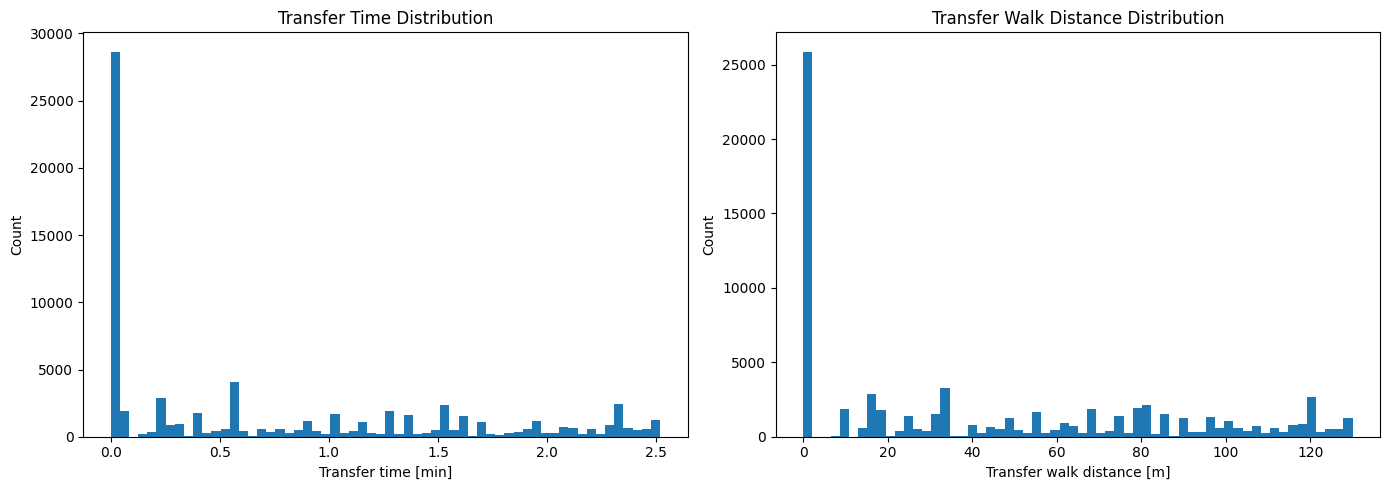

In [5]:
transfers = transfers.copy()
transfers['transfer_time_min'] = transfers['transfer_time_s'] / 60.0
transfers['transfer_distance_m'] = transfers['transfer_distance_m'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(transfers['transfer_time_min'], bins=60)
axes[0].set_title('Transfer Time Distribution')
axes[0].set_xlabel('Transfer time [min]')
axes[0].set_ylabel('Count')

axes[1].hist(transfers['transfer_distance_m'], bins=60)
axes[1].set_title('Transfer Walk Distance Distribution')
axes[1].set_xlabel('Transfer walk distance [m]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
top_transfers = transfers.sort_values(['transfer_time_s', 'transfer_distance_m'], ascending=False).head(10)
top_transfers

,person,trip_id,pt_legs_in_trip,transfer_index,prev_pt_dep_time,prev_pt_arrival_time,next_pt_dep_time,transfer_time_s,transfer_walk_time_s,transfer_wait_time_s,...,prev_transit_line,prev_transit_route,next_transit_line,next_transit_route,prev_egress_stop_id,next_access_stop_id,estimated_walk_speed_kmh,estimated_walk_time_s,estimated_wait_time_s,transfer_time_min
19,person_100069__men__70_to_74_years__1_basic__u...,person_100069__men__70_to_74_years__1_basic__u...,3,2,18:49:26,19:16:00,19:18:31,151.0,151.0,0.0,...,705,705_1_F_52,205,205_0_F_174,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
494,person_101289__men__45_to_49_years__undergradu...,person_101289__men__45_to_49_years__undergradu...,3,2,10:54:27,13:56:47,13:59:18,151.0,151.0,0.0,...,601,601_1_F_2,200,200_0_F_18,PRG2.link:2702,PRG4.link:121643,4.0,117.0,34.0,2.516667
618,person_101661__men__30_to_34_years__undergradu...,person_101661__men__30_to_34_years__undergradu...,3,2,12:15:02,13:14:03,13:16:34,151.0,151.0,0.0,...,705,705_1_F_6,205,205_0_F_66,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
1029,person_102616__men__30_to_34_years__3_basic__w...,person_102616__men__30_to_34_years__3_basic__w...,2,1,18:34:12,19:15:59,19:18:30,151.0,151.0,0.0,...,705,705_1_F_52,704,704_1_F_58,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
1074,person_102691__men__45_to_49_years__no_educati...,person_102691__men__45_to_49_years__no_educati...,3,2,08:27:53,09:25:09,09:27:40,151.0,151.0,0.0,...,705,705_1_F_34,704,704_1_F_61,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
1202,person_103175__men__45_to_49_years__3_basic__w...,person_103175__men__45_to_49_years__3_basic__w...,2,1,11:49:36,12:13:25,12:15:56,151.0,151.0,0.0,...,303,303_0_F_8,508,508_0_F_54,CZV4.link:379905,CZV1.link:164359,4.0,117.0,34.0,2.516667
1744,person_104743__men__45_to_49_years__undergradu...,person_104743__men__45_to_49_years__undergradu...,2,1,11:02:23,12:08:02,12:10:33,151.0,151.0,0.0,...,705,705_1_F_6,205,205_0_F_66,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
1829,person_104988__men__35_to_39_years__3_basic__r...,person_104988__men__35_to_39_years__3_basic__r...,3,2,13:44:29,14:34:03,14:36:34,151.0,151.0,0.0,...,705,705_1_F_6,205,205_0_F_124,ASPL1.link:373231,IPO5.link:387375,4.0,117.0,34.0,2.516667
1870,person_10508__men__50_to_54_years__3_basic__wo...,person_10508__men__50_to_54_years__3_basic__wo...,3,2,20:40:13,22:09:05,22:11:36,151.0,151.0,0.0,...,704,704_1_F_41,600,600_0_F_155,AZ.link:89066,AML1.link:89059,4.0,117.0,34.0,2.516667
1947,person_105238__men__60_to_64_years__highschool...,person_105238__men__60_to_64_years__highschool...,2,1,12:15:37,22:14:19,22:16:50,151.0,151.0,0.0,...,208,208_1_F_9,207,207_0_F_60,PRG2.link:2702,PRG4.link:121643,4.0,117.0,34.0,2.516667


## Transfer Routes Analysis
Analysis of the most common PT line-to-line transfers, stops, and wait times.

In [40]:
# Most common PT line-to-line transfers
# Create a transfer route identifier (line_x -> line_y)
transfers_analysis = transfers.copy()
transfers_analysis['transfer_route'] = (
    transfers_analysis['prev_transit_line'].astype(str) + 
    ' → ' + 
    transfers_analysis['next_transit_line'].astype(str)
)

# Count transfers by route and get statistics
line_transfers = transfers_analysis.groupby('transfer_route', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median', 'min', 'max'],
    'estimated_wait_time_s': ['mean', 'median', 'max'],
    'estimated_walk_time_s': ['mean', 'sum'],
    'transfer_distance_m': ['mean', 'sum'],
}).round(2)

# Flatten column names
line_transfers.columns = ['_'.join(col).strip('_') for col in line_transfers.columns.values]
line_transfers.columns = ['transfer_route', 'count', 'mean_transfer_time_s', 'median_transfer_time_s', 
                          'min_transfer_time_s', 'max_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'total_walk_time_s',
                          'mean_distance_m', 'total_distance_m']

In [42]:
# Sort by frequency
line_transfers = line_transfers.sort_values('count', ascending=False)

line_transfers[['transfer_route', 'count', 'mean_transfer_time_s', 'mean_wait_time_s', 'mean_distance_m']].head(10)

,transfer_route,count,mean_transfer_time_s,mean_wait_time_s,mean_distance_m
1935,D → 500,1526,35.0,5.3,33.0
1922,C → D,1526,0.0,0.0,0.0
2036,F → D,1150,0.0,0.0,0.0
1959,D → C,1084,0.0,0.0,0.0
1851,B → D,950,0.0,0.0,0.0
1961,D → F,884,0.0,0.0,0.0
1999,E → D,739,0.0,0.0,0.0
1886,Bexp → D,721,0.0,0.0,0.0
1957,D → B,703,0.0,0.0,0.0
1960,D → E,648,0.0,0.0,0.0


In [43]:
transfers_analysis['transfer_route_w_stops'] = (
    transfers_analysis['prev_transit_line'].astype(str) +
        ' @ ' +
    transfers_analysis['prev_egress_stop_id'].astype(str) +
    ' → ' + 
    transfers_analysis['next_transit_line'].astype(str) +
        ' @ ' +
    transfers_analysis['next_access_stop_id'].astype(str)
)

# Count transfers by route and get statistics
line_stop_transfers = transfers_analysis.groupby('transfer_route_w_stops', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median', 'min', 'max'],
    'estimated_wait_time_s': ['mean', 'median', 'max'],
    'estimated_walk_time_s': ['mean', 'sum'],
    'transfer_distance_m': ['mean', 'sum'],
}).round(2)

# Flatten column names
line_stop_transfers.columns = ['_'.join(col).strip('_') for col in line_stop_transfers.columns.values]
line_stop_transfers.columns = ['transfer_route', 'count', 'mean_transfer_time_s', 'median_transfer_time_s', 
                          'min_transfer_time_s', 'max_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'total_walk_time_s',
                          'mean_distance_m', 'total_distance_m']

#time in minutes
for col in line_stop_transfers.columns:
    if 'time_s' in col:
        line_stop_transfers[col.replace('_s', '_m')] = line_stop_transfers[col] / 60.0

In [68]:
# Sort by frequency
line_stop_transfers = line_stop_transfers.sort_values(['mean_transfer_time_s','count'], ascending=False)

# Filter routes with at least 10 transfers for meaningful statistics
significant_routes = line_stop_transfers[line_stop_transfers['count'] >= 10]
significant_routes[['transfer_route', 'count', 'mean_transfer_time_m', 'mean_wait_time_m', 'mean_distance_m']].head(10)

,transfer_route,count,mean_transfer_time_m,mean_wait_time_m,mean_distance_m
3133,705 @ ASPL1.link:373231 → 205 @ IPO5.link:387375,181,2.516667,0.566667,130.0
1574,402 @ CZV4.link:379905 → 508 @ CZV1.link:164359,54,2.516667,0.566667,130.0
3134,705 @ ASPL1.link:373231 → 301 @ IPO5.link:387375,52,2.516667,0.566667,130.0
3137,705 @ ASPL1.link:373231 → 704 @ IPO5.link:387375,40,2.516667,0.566667,130.0
2995,704 @ AZ.link:89066 → 600 @ AML1.link:89059,27,2.516667,0.566667,130.0
1575,402 @ CZV4.link:379905 → 602 @ CZV1.link:164359,22,2.516667,0.566667,130.0
1198,303 @ CZV4.link:379905 → 508 @ CZV1.link:164359,15,2.516667,0.566667,130.0
1573,402 @ CZV4.link:379905 → 300 @ CZV1.link:164359,10,2.516667,0.566667,130.0
2337,600 @ AML4.link:122179 → 205 @ AML3.link:260662,150,2.500000,0.565000,129.0
1733,500 @ FLU3.link:143276 → 504 @ FLU1.link:63587,20,2.500000,0.565000,129.0


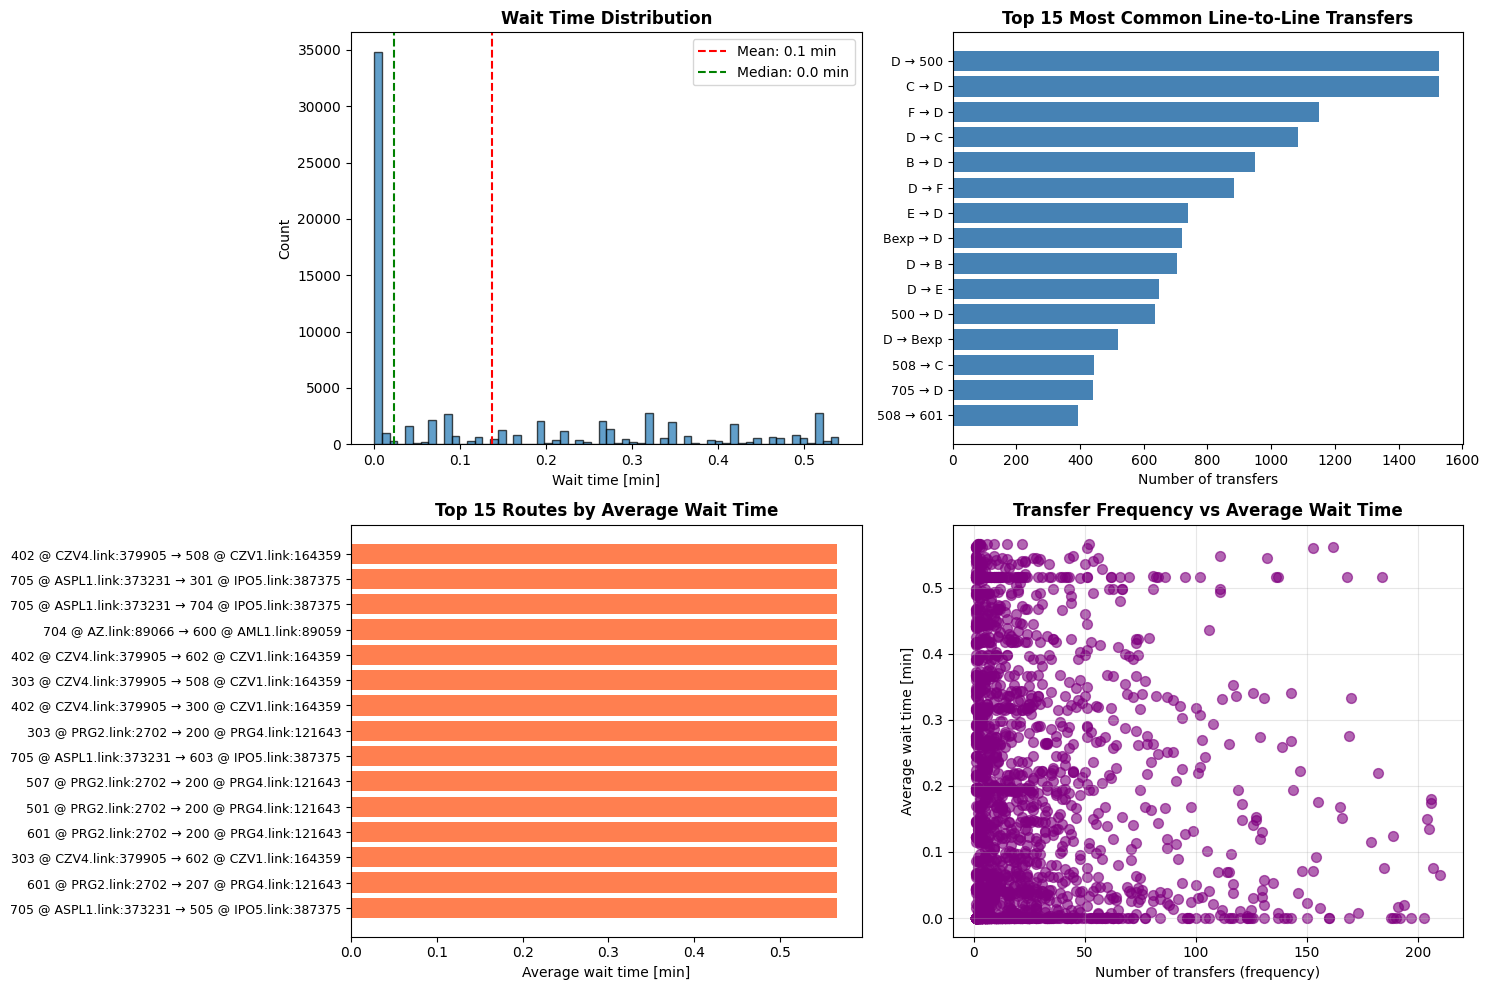

In [79]:
# Visualizations: Distribution of wait times and top transfers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Wait time distribution
wait_times_min = transfers_analysis['estimated_wait_time_s'] / 60
wait_times_min = wait_times_min[wait_times_min.between(wait_times_min.quantile(0.025), wait_times_min.quantile(0.975))]
axes[0, 0].hist(wait_times_min, bins=60, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Wait Time Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Wait time [min]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(wait_times_min.mean(), color='red', linestyle='--', label=f'Mean: {wait_times_min.mean():.1f} min')
axes[0, 0].axvline(wait_times_min.median(), color='green', linestyle='--', label=f'Median: {wait_times_min.median():.1f} min')
axes[0, 0].legend()

# Plot 2: Top 15 routes by frequency
top_15_routes = line_transfers.head(15)
axes[0, 1].barh(range(len(top_15_routes)), top_15_routes['count'], color='steelblue')
axes[0, 1].set_yticks(range(len(top_15_routes)))
axes[0, 1].set_yticklabels(top_15_routes['transfer_route'], fontsize=9)
axes[0, 1].set_xlabel('Number of transfers')
axes[0, 1].set_title('Top 15 Most Common Line-to-Line Transfers', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
#for i, v in enumerate(top_15_routes['count']): axes[0, 1].text(v + 50, i, str(int(v)), va='center')

# Plot 3: Top 15 routes by average wait time (only routes with 10+ transfers)
top_15_wait = line_stop_transfers[line_stop_transfers['count'].between(line_stop_transfers['count'].quantile(0.025), line_stop_transfers['count'].quantile(0.975))].head(15)
axes[1, 0].barh(range(len(top_15_wait)), top_15_wait['mean_wait_time_m'], color='coral')
axes[1, 0].set_yticks(range(len(top_15_wait)))
axes[1, 0].set_yticklabels(top_15_wait['transfer_route'], fontsize=9)
axes[1, 0].set_xlabel('Average wait time [min]')
axes[1, 0].set_title('Top 15 Routes by Average Wait Time', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
#for i, v in enumerate(top_15_wait['mean_wait_time_m']):axes[1, 0].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)

# Plot 4: Relationship between transfer frequency and average wait time
transferCounts = line_transfers[line_transfers['count'].between(line_transfers['count'].quantile(0.025), line_transfers['count'].quantile(0.975))]
axes[1, 1].scatter(transferCounts['count'], transferCounts['mean_wait_time_s'] / 60, 
                   s=50, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Number of transfers (frequency)')
axes[1, 1].set_ylabel('Average wait time [min]')
axes[1, 1].set_title('Transfer Frequency vs Average Wait Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()